# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Wendy Oosterhof
* Username: wroosterhof
* Student number: s6328091
* Group (AS1, etc.): AS6

-----

In [ ]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [2]:
import numpy as np
import sympy as sp
from scipy.integrate import quad
from math import sin

#Defining all of the functions inside the class: integration.
class integration:
    def __init__(self, function, a, b):
        self.f = function
        self.a = a
        self.b = b
        
    def Trapezium(self):
        """Evaluates the integral using the Trapezium method."""
        x = self.a
        fa = eval(self.f)
        x = self.b
        fb = eval(self.f)
        I = (self.b-self.a)*((fa+fb)/2)
        return I

    def Simpson(self):
        """Evaluates the integral using the Simpson integration method."""
        total = 0 #Sets the total to 0.
        n = 1000 #Sets the length.
        x = np.linspace(self.a, self.b, n + 1) #Makes an uniform array.
        f = lambda x_val: eval(self.f, {"x": x_val, "np": np, "sin": np.sin, "cos": np.cos, "exp": np.exp}) #Defines the string as a usable function.
        total = f(x[0]) + f(x[-1]) #Gets the f(x_0) + f(x_n) since they only have a coefficient of 1 each, we can just add them to start out the total.
        total += 4*f(x[1:-1:2]).sum() #Adds the uneven index values with the coefficient of 4 to the total.
        total += 2*f(x[2:-2:2]).sum() #Adds the even index values with the coefficient of 2 to the total.
        h = (self.b-self.a)/n #Calculates the h (h = (b-a)/n
        result = (h/3) * total #Calculates the result.
        return result #Returns the results.

    def Monte(self):
        """Evaluates the integral using the Monte Carlo integration method."""
        x = np.random.uniform(self.a, self.b, 10000)
        f = lambda x_val: eval(self.f, {"x": x_val, "np": np, "sin": np.sin, "cos": np.cos, "exp": np.exp})  # evaluate f at all sampled points
        result = (self.b - self.a) * np.mean(f(x))
        return result

    def Sympy_int(self):
        """Evaluates the integral using sympy.integrate."""
        x = sp.symbols("x") #Defines x as a symbol used in the rest of the code.
        f = sp.sympify(self.f) #Turns it into a simpy usable function.
        inte = sp.integrate(f, (x, self.a, self.b)) #Calculates the integral of f over x on the specified interval.
        result = inte.evalf(3)
        return result

    def Quad(self):
        """Evaluates the integral using scipy.integrate.quad()."""
        n = 1000 #Sets the length.
        x = np.linspace(self.a, self.b, n + 1)
        f = lambda x: eval(self.f) #Defines the string as a usable function.
        inte, err = quad(f, self.a, self.b) #Integrates the function and separates the tuple outcome to two variables.
        return inte
        
    
        
def printing(function, a, b):
    """Function to print all of the outcomes at once instead of typing it over and over again."""
    inte = integration(function, a, b)
    print(f"The area under the graph of function {function} between {a} and {b}:")
    print(f"Trapezium: {inte.Trapezium():.2f}")
    print(f"Simpson: {inte.Simpson():.2f}")
    print(f"Monte: {inte.Monte():.2f}")
    print(f"Sympy: {inte.Sympy_int():.2f}")
    print(f"Quad: {inte.Quad():.2f}")

#Printing the testing cases.
printing("x", 1, 2)
print("\n")
printing("1 + x + sin(2*x)", 1, 2)

The area under the graph of function x between 1 and 2:
Trapezium: 1.50
Simpson: 1.50
Monte: 1.50
Sympy: 1.50
Quad: 1.50


The area under the graph of function 1 + x + sin(2*x) between 1 and 2:
Trapezium: 2.58
Simpson: 2.62
Monte: 2.62
Sympy: 2.62
Quad: 2.62


In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

Filename: /Users/users/wroosterhof/PROGNUM-repo/Task6/ngc6946.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     205   (100, 100, 101)   float32   


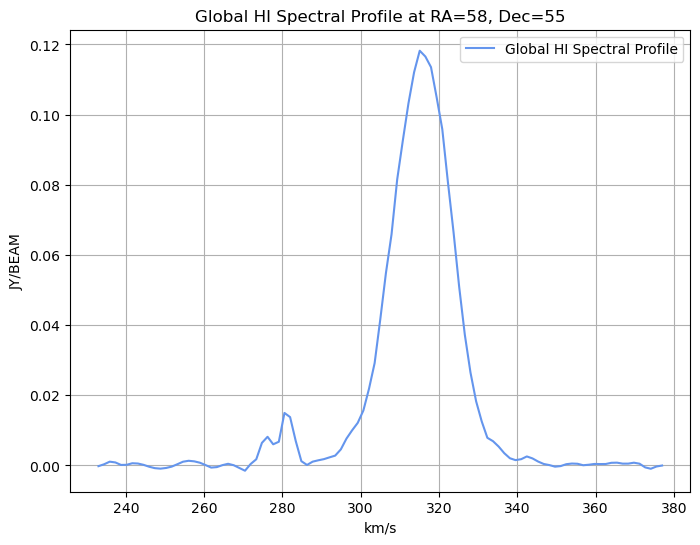

In [14]:
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits

#Importing the fits file.
hdulist = fits.open('~/PROGNUM-repo/Task6/ngc6946.fits')
dat = hdulist[0].data
hdulist.info()
hdr = hdulist[0].header

profile1 = dat[:,55,58] #Slicing the data for given specifications.
profile = np.array(profile1, dtype = float)
#Defining starting and ending points for v.
v_start = 233
v_end = 377
velocity = np.linspace(v_start, v_end, len(profile), dtype = float) #Making an array of same length as profile starting at v_start and ending at v_end.

#Plotting global HI spectral profile.
fig = plt.figure(figsize = (8,6))
frame = fig.add_subplot(1,1,1)
plt.plot(velocity, profile, color = "cornflowerblue", label = "Global HI Spectral Profile")
frame.set_xlabel(hdr["CUNIT3"])
frame.set_ylabel(hdr["BUNIT"])
frame.set_title("Global HI Spectral Profile at RA=58, Dec=55")
frame.legend()
frame.grid()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [4]:
import numpy as np
import sympy as sp
#Sympy version for the derivatives.
def f_sp(x, amp, mu, sigma, zero):
    return amp * sp.exp(-((x - mu)**2) / (2 * sigma**2)) + zero

#Numpy version for the calculations.
def f_np(x, amp, mu, sigma, zero):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2)) + zero

In [ ]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

In [5]:
# Defining the symbols
x, amp, mu, sigma, zero = sp.symbols('x amp mu sigma zero')

func = f_sp(x, amp, mu, sigma, zero)

# Calculate derivatives with respect to the parameters
diff_amp = sp.diff(func, amp)
diff_mu = sp.diff(func, mu)
diff_sigma = sp.diff(func, sigma)

#----PRINTING TIME-----
print(f"Derivative w.r.t. amplitude: {diff_amp}")
print(f"The derivatice w.r.t. the amplitude does not have another term of amplitude anymore, and therefore is liner.")
print(f"\nDerivative w.r.t. mu: {diff_mu}")
print(f"The derivative w.r.t. mu does have another term of mu, meaning it's non-linear.")
print(f"\nDerivative w.r.t. sigma: {diff_sigma}")
print(f"The derivative w.r.t. sigma does have another term of sigma, meaning it's non-linear.")
print(f"\nSince both mu and sigma lead to a non-linear outcome, the whole function of f is non-linear.")

Derivative w.r.t. amplitude: exp(-(-mu + x)**2/(2*sigma**2))
The derivatice w.r.t. the amplitude does not have another term of amplitude anymore, and therefore is liner.

Derivative w.r.t. mu: -amp*(2*mu - 2*x)*exp(-(-mu + x)**2/(2*sigma**2))/(2*sigma**2)
The derivative w.r.t. mu does have another term of mu, meaning it's non-linear.

Derivative w.r.t. sigma: amp*(-mu + x)**2*exp(-(-mu + x)**2/(2*sigma**2))/sigma**3
The derivative w.r.t. sigma does have another term of sigma, meaning it's non-linear.

Since both mu and sigma lead to a non-linear outcome, the whole function of f is non-linear.


In [ ]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [6]:
from scipy.optimize import curve_fit

esti_z = np.min(profile) #Takes the minimum of the JY/BEAM, giving us the baseline.

#---Handpicked from the graph----
esti_m = 315 #Is around the mean of the graph.
esti_amp = 0.12 #Is around the amplitude of the graph.
esti_sig = 15 #Is around the length of going from the peak to one of the sides.

#Curvefitting
p0_list = [esti_amp, esti_m, esti_sig, esti_z] #Makes a list of the above specified estimates.
popt, pcov = curve_fit(f_np, velocity, profile, p0=p0_list) #Works on the curve fit using the numpy specified function.
perr = np.sqrt(np.diag(pcov)) #Calculates the errors.

v_fine = np.linspace(velocity.min(), velocity.max(), 500) #Getting a velocity range.
profile_fit = f_np(v_fine, *popt)

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

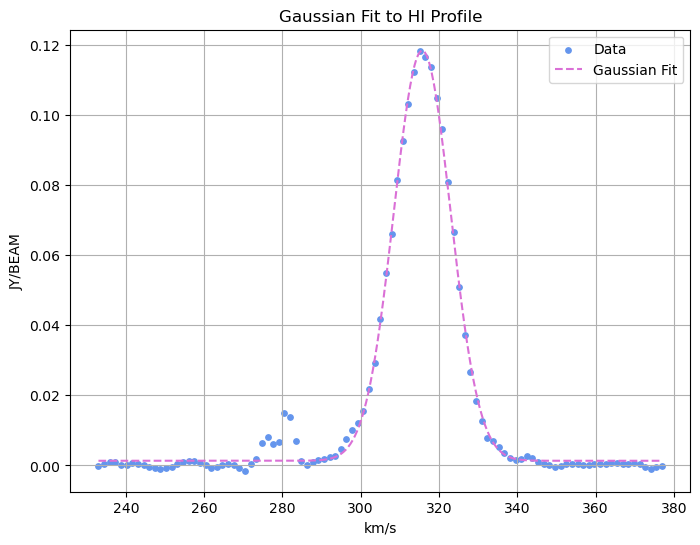

In [7]:
from matplotlib import pyplot as plt


fig = plt.figure(figsize=(8, 6))
frame = fig.add_subplot(1,1,1)
# Original Data
frame.scatter(velocity, profile, color="cornflowerblue", label="Data", s = 15)
# Best Fit
frame.plot(v_fine, profile_fit, color="orchid", linestyle="--", label="Gaussian Fit")
frame.set_xlabel(hdr["CUNIT3"])
frame.set_ylabel(hdr["BUNIT"])
frame.set_title("Gaussian Fit to HI Profile")
frame.legend()
frame.grid()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

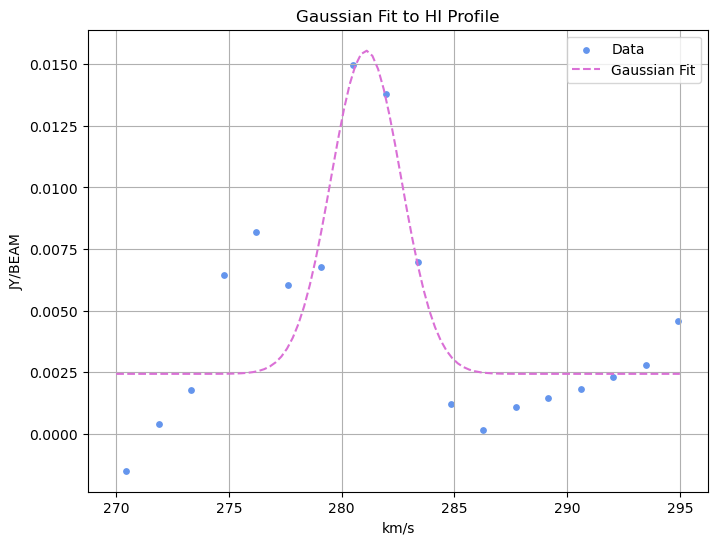

In [8]:
zoom_mask = (velocity >= 270) & (velocity <= 295) #Makes sure only the small peak is taken in consideration. (Zoomie zoomie)

#Applying the zoom mask.
v_small = velocity[zoom_mask]
p_small = profile[zoom_mask]

p0_small = [0.015, 280, 3, esti_z] #Estimates of the starting coefficients. [amp, mu, sigma, zero].
"""
All taken from the little graph:
amplitude = 0.015
mu = 280
sigma = 3
"""

#Fitting on the smaller data to make sure the big peak isn't to distracting for the fit.
popt1, pcov1 = curve_fit(f_np, v_small, p_small, p0=p0_small)
perr1 = np.sqrt(np.diag(pcov1)) #Error time!

v_fine1 = np.linspace(270, 295, 100) #Making the x values.
profile_fit1 = f_np(v_fine1, *popt1) #Getting the fit.

# --- PLOT ---
fig = plt.figure(figsize=(8, 6))
frame = fig.add_subplot(1,1,1)
frame.scatter(v_small, p_small, color="cornflowerblue", label="Data", s = 15)
# Best Fit
frame.plot(v_fine1, profile_fit1, color="orchid", linestyle="--", label="Gaussian Fit")
frame.set_xlabel(hdr["CUNIT3"])
frame.set_ylabel(hdr["BUNIT"])
frame.set_title("Gaussian Fit to HI Profile")
frame.legend()
frame.grid()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [12]:
def FWHM(x, sigma, sigma_err):
    """Calculates the FWHM using the sigma and the error of sigma of the fits."""
    result = 2*sigma*np.sqrt(2*np.log(2)) #Calculates the results using the formula given in the description of the FWHM.
    error = 2*np.sqrt(2*np.log(2))*sigma_err #Calculates the error of the result using the formula given in the description of the FWHM.
    return result, error #Returning those numbers.

#Defining the peaks and printing the results.
main, m_err = FWHM(x, popt[2], perr[2]) #The third in the popt and perr list is the sigma.
print(f"The FWHM of the main peak is {main:.1f} km/s with an error of {m_err:.1f} km/s.")
small, s_err = FWHM(x, popt1[2], perr1[2])
print(f"The FWHM of the smaller peak is {small:.1f} with an error of {s_err:.1f} km/s.")

The FWHM of the main peak is 17.1 km/s with an error of 0.2 km/s.
The FWHM of the smaller peak is 3.7 with an error of 0.8 km/s.


In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

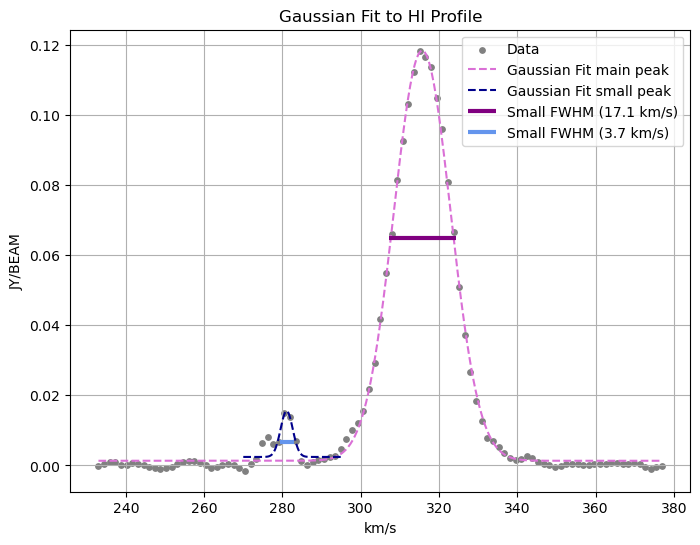

In [15]:
fig = plt.figure(figsize=(8, 6))
frame = fig.add_subplot(1,1,1)
# Original Data
frame.scatter(velocity, profile, color="gray", label="Data", s = 15)
frame.plot(v_fine, profile_fit, color="orchid", linestyle="--", label="Gaussian Fit main peak")
frame.plot(v_fine1, profile_fit1, color="darkblue", linestyle="--", label="Gaussian Fit small peak")
frame.hlines(y=0.065, #Halfway up the peak due to plotting it at 1/2 the amplitude.
           xmin=popt[1] - (main/2), #Starting point (sigma - FWHM of main peak).
           xmax=popt[1] + (main/2), #Ending point (sigma + FWHM of main peak).
           color="purple", lw=3, label=f"Small FWHM ({main:.1f} km/s)")
frame.hlines(y=popt1[0]/2, #Halfway up the peak due to plotting it at 1/2 the amplitude.
           xmin=popt1[1] - (small/2), #Starting point (sigma - FWHM of small peak).
           xmax=popt1[1] + (small/2), #Ending point (sigma + FWHM of small peak).
           color="cornflowerblue", lw=3, label=f"Small FWHM ({small:.1f} km/s)")
frame.set_xlabel(hdr["CUNIT3"])
frame.set_ylabel(hdr["BUNIT"])
frame.set_title("Gaussian Fit to HI Profile")
frame.legend()
frame.grid()
plt.show()

hdulist.close() #Closing the fits at last.

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   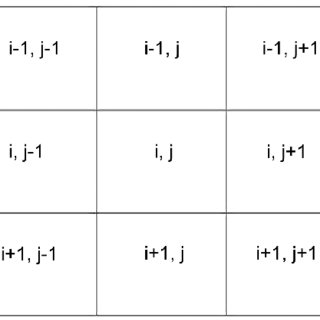    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

Filename: /Users/users/wroosterhof/PROGNUM-repo/Task7/faintgalaxy.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (200, 160)   float64   


Text(0.5, 1.0, 'Using smooth2()')

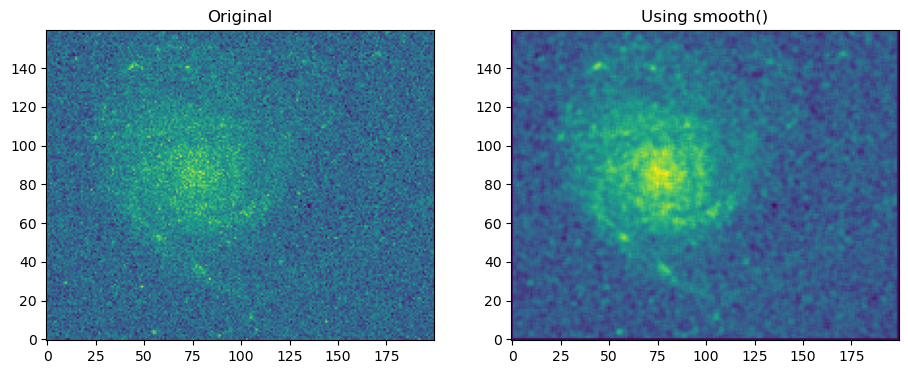

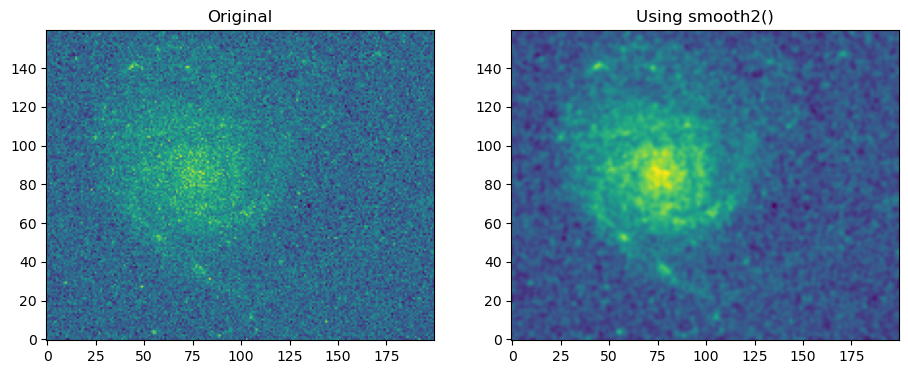

In [17]:
from astropy.io import fits
import numpy as np
from matplotlib import pyplot as plt
from scipy import ndimage

hdulist = fits.open('~/PROGNUM-repo/Task7/faintgalaxy.fits')
M = hdulist[0].data
hdulist.info()
hdr = hdulist[0].header

def smooth(M):
    rows, cols = M.shape #Gets the dimensions of the original image.
    Mc = np.zeros((rows, cols), dtype = M.dtype) #Makes an array of zeros in the shape of M and with the same data type.
    for i in range(1, rows-1): #Goes from index 1 to the second to last index to keep the outsides 0.
        for j in range(1, cols-1): #Same as before.
            around = M[i-1:i+2, j-1:j+2] #i-1, pixels left to the wanted pixel, i+2 since it means it stops before the end point, doing the same for j gives a 3x3 slice.
            meanpix = np.mean(around)
            Mc[i,j] = meanpix
    return Mc

A = smooth(M)
#Plotting time!
fig, axes = plt.subplots(1, 2, figsize=(11, 11))
axes[0].imshow(M, origin = "lower")
axes[0].set_title("Original")
axes[1].imshow(A, origin = "lower")
axes[1].set_title("Using smooth()")

def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
B = smooth2(M)

#Plotting time 2!
fig, axes = plt.subplots(1, 2, figsize=(11, 11))
axes[0].imshow(M, origin = "lower")
axes[0].set_title("Original")
axes[1].imshow(B, origin = "lower")
axes[1].set_title("Using smooth2()")

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")